<font size=10>**GENERAL DATA PREPROCESSING**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

<u>Text Structure</u> + <u>Vocabulary</u>

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Text Structure](#3)
- [4. General Text Preprocessing](#4)
- [5. Vocabulary](#5)
- [6. Non-English Reviews - Detection and Translation](#6)
- [7. Feature Extraction](#7)
    - [7.1 TF-IDF](#7_1)
    - [7.2 Counter](#7_2)
- [8. Visualizations](#8)
    - [8.1 Categories](#8_1)
    - [8.2 Ratings](#8_2)
    

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
# pip install deep-translator
# pip install langdetect
# pip install langid
# pip install emoji

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd
import regex as re
from collections import Counter
import Levenshtein
from jellyfish import jaro_winkler_similarity

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from general_preprocessing import *
from visualizations import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/01_atlanta_restaurant_slice_2023_new_features.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text,is_chain,total_reviews_by_title,latitude,longitude
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",False,3349,33.779814,-84.410451
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,False,3349,33.779814,-84.410451
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,False,3349,33.779814,-84.410451
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,False,3349,33.779814,-84.410451
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,False,3349,33.779814,-84.410451


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   53566 non-null  object 
 1   categoryName            53566 non-null  object 
 2   website                 50600 non-null  object 
 3   url                     53566 non-null  object 
 4   reviewsCount            53566 non-null  int64  
 5   stars                   53566 non-null  float64
 6   text                    53566 non-null  object 
 7   is_chain                53566 non-null  bool   
 8   total_reviews_by_title  53566 non-null  int64  
 9   latitude                53566 non-null  float64
 10  longitude               53566 non-null  float64
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 4.1+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Text Structure**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

In [7]:
# TODO: See how many sentences do we have in the 'review_text' column
dataset['num_sentences'] = dataset['text'].apply(lambda x: len(str(x).split('. ')))

In [8]:
dataset['num_sentences'].describe()

count    53566.000000
mean         2.783071
std          2.657222
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         43.000000
Name: num_sentences, dtype: float64

In [9]:
histogram_chart(
    data=dataset,
    column='num_sentences',
    title='Number of Sentences per Review',
    x_label='Number of Sentences'
)

# <font color='#BFD72F' size=6>**4. General Text Preprocessing**</font> <a class="anchor" id="4"></a>
  
[Back to TOC](toc)


1. **Clean Data** — Remove Extraneous Content (Part 1 & Part 2)

2. **Transform Data** — Tokenization, POS Tagging, Stopword Removal
After translation and cleaning, we tokenize the text, apply part‑of‑speech tagging, and remove stopwords (except those explicitly retained).

3. **Normalize Data** — Case, Stemming, Lemmatization
Finally, we normalize the text by lowercasing, stemming, and lemmatizing, ensuring consistent word forms for analysis.

## <font color='#BFD72F' size=6>4.1 Clean Data</font> <a class="anchor" id="4_1"></a>
  
[Back to TOC](toc)

**Remove Extraneous Content (Part 1 & Part 2)**

During preprocessing we discovered that some reviews were written in languages other than English. This posed a risk to downstream tasks such as lemmatization, tokenization, and stopword removal, since these steps rely on English linguistic rules. To ensure consistency and reliability, we decided to identify non‑English reviews and translate them into English before applying deeper transformations.

Because translation must occur at the right stage, the cleaning step was split into two parts:

- Part 1 — Pre‑Translation Cleaning
In this stage we remove elements that cannot or should not be translated, such as emojis, hashtags, newlines, and URLs.  
    - Emojis are converted into textual tokens (e.g., ❤️ → `emoji_red_heart`).  
    - Hashtags are normalized by retaining the word but removing the `@` symbol (e.g., `#great` → `great`).  
    - URLs are replaced by their main domain entity (e.g., `www.instagram.com` → `instagram`).  
    - Newlines are replaced with spaces to ensure continuity.  

After this step, the text is safe to pass through translation without losing semantic meaning or introducing noise.

- Translation
Non‑English reviews are detected using language identification tools and translated into English. This ensures that subsequent linguistic transformations are applied consistently across the dataset.

- Part 2 — Post‑Translation Cleaning
Once reviews are translated, we apply additional cleaning steps that are safe to perform on English text:  
    - Diacritics are converted to plain characters.  
    - Punctuation is removed.  
    - Repeated characters are normalized (e.g., `"soooo"` → `"soo"`).  
    - Stopwords are retained for now, but exceptions such as `again` and `not` are preserved to maintain negation and emphasis.  

This two‑step process ensures that translation happens at the right moment:  
- **Not before cleaning**, because emojis, hashtags, and URLs cannot be translated meaningfully.  
- **Not after heavy normalization**, because translation requires the original linguistic structure.  

In [10]:
# Part 1
dataset['00_before_translating_cleaning'] = dataset['text'].apply(
    lambda x: main_pipeline(
        print_output=False,
        raw_text=x,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=False,
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [11]:
dataset['00_before_translating_cleaning'].head()

0    One word amazing!! The red fish, halibut, frie...
1    First time here and the food is great and the ...
2    I recently had the pleasure of dining at Optim...
3    Beautiful atmosphere and delicious food . All ...
4    We had a wonderful dinner at the Optimist . Ou...
Name: 00_before_translating_cleaning, dtype: object

In [12]:
dataset[['text', '00_before_translating_cleaning']].iloc[[4854, 18086, 21008, 29289, 42324, 42803, 44987]]

,text,00_before_translating_cleaning
4854,❤️,emoji_red_heart
18086,✔️,emoji_check_mark
21008,⭐⭐⭐⭐⭐,emoji_staremoji_staremoji_staremoji_staremoji_...
29289,️,
42324,❤️❤️❤️❤️,emoji_red_heartemoji_red_heartemoji_red_hearte...
42803,❤️,emoji_red_heart
44987,♥️,emoji_heart_suit


In [13]:
dataset['text'].iloc[29289].strip()

'️'

In [14]:
# Dropping the problematic row
dataset.drop(29289, inplace=True)

In [15]:
# Detecting and Translating Non-English Reviews
dataset = MainPipeline.process_and_translate_dataset(dataset)

In [16]:
dataset.columns

Index(['title', 'categoryName', 'website', 'url', 'reviewsCount', 'stars',
       'text', 'is_chain', 'total_reviews_by_title', 'latitude', 'longitude',
       'num_sentences', '00_before_translating_cleaning', 'lang_langdetect',
       'lang_langid', 'needs_translation', 'text_translated',
       'text_for_pipeline'],
      dtype='object')

In [17]:
dataset.isnull().sum()

title                                0
categoryName                         0
website                           2966
url                                  0
reviewsCount                         0
stars                                0
text                                 0
is_chain                             0
total_reviews_by_title               0
latitude                             0
longitude                            0
num_sentences                        0
00_before_translating_cleaning       0
lang_langdetect                      3
lang_langid                          0
needs_translation                    0
text_translated                      0
text_for_pipeline                    0
dtype: int64

In [18]:
dataset['needs_translation'].value_counts(normalize=True) * 100

needs_translation
False    91.442173
True      8.557827
Name: proportion, dtype: float64

In [19]:
dataset[dataset['needs_translation'] == True][['text', 'text_for_pipeline']] \
    .reset_index()[['index', 'text', 'text_for_pipeline']] \
    .sample(1, random_state=60).values

array([[38159,
        'Ambiente tranquilo  tienen  máquina de moneda,  billar ,tv ,menu de aperitivo y bebidas alcohólicas  ,buen trato y buen servicio!!',
        'Quiet atmosphere, they have a coin machine, billiards, TV, appetizer menu and alcoholic drinks, good treatment and good service!!']],
      dtype=object)

In [20]:
export_dataset(dataset, 
               '../data', 
               '02_atlanta_restaurant_slice_2023_translated',
                'csv'
                ) 

In [21]:
# Part 2
dataset['01_cleaned_text'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=False,             # already handled in Part 1
        no_hashtags=False,           # already handled in Part 1
        hashtag_retain_words=False,  # already handled in Part 1
        no_newlines=False,           # already handled in Part 1
        no_urls=False,
        no_punctuation=False,   # Best practice: remove punctuation after tokenization, since some marks (e.g. apostrophes in "don't") are part of valid tokens
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=['again', 'not'],
        convert_diacritics=True,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

## <font color='#BFD72F' size=6>4.2 Transform Data</font> <a class="anchor" id="4_2"></a>
  
[Back to TOC](toc)

**Tokenization, POS Tagging, Stopword Removal**

After translation and cleaning, we tokenize the text, apply part‑of‑speech tagging, and remove stopwords (except those explicitly retained).

*Note*: 
It is generally better to **tokenize before removing punctuation**, since punctuation marks can be part of valid tokens (e.g., `"don't"`, `"it's"`). This preserves word integrity while still removing unwanted symbols.

In [22]:
# Part 3
dataset['02_transformed_text'] = dataset['01_cleaned_text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=False,             
        no_hashtags=False,           
        hashtag_retain_words=True,  
        no_newlines=False,           
        no_urls=False,
        no_punctuation=False,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=['again'],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[], #'n', 'v', 'a', 'r', 's'
        pos_tags_list='no_pos',
        tokenized_output=True,
        stemmed=False,
        treat_repeated_chars=False
    )
)

## <font color='#BFD72F' size=6>4.3 Normalize Data</font> <a class="anchor" id="4_3"></a>
  
[Back to TOC](toc)

**Case, Stemming, Lemmatization**

Finally, we normalize the text by lowercasing, stemming, and lemmatizing, ensuring consistent word forms for analysis.

In [24]:
# Part 3
dataset['03_normalized_text'] = dataset['02_transformed_text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=False,             
        no_hashtags=False,           
        hashtag_retain_words=True,  
        no_newlines=False,           
        no_urls=False,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=True,
        list_pos=['n', 'v', 'a', 'r', 's'],
        pos_tags_list='pos_tuples',
        tokenized_output=True,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [27]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].iloc[52589].values)

print("\nTranslated Text Sample:\n")
print(dataset[['text_for_pipeline']].iloc[52589].values)

print("\nCleaned Text Sample:\n")
print(dataset[['01_cleaned_text']].iloc[52589].values)

print("\nTransformed Text Sample:\n")
print(dataset[['02_transformed_text']].iloc[52589].values)

print("\nNormalized Text Sample:\n")
print(dataset[['03_normalized_text']].iloc[52589].values)


Original Text Sample:

['An enjoyable place to eat!!! Delicious food!!!']

Translated Text Sample:

['An enjoyable place to eat!!! Delicious food!!!']

Cleaned Text Sample:

['An enjoyable place to eat!!! Delicious food!!!']

Transformed Text Sample:

[list(['enjoyable', 'place', 'eat', '!', '!', '!', 'Delicious', 'food', '!', '!', '!'])]

Normalized Text Sample:

[list([("'enjoyable", 'JJ'), ('place', 'NN'), ('eat', 'NN'), ('delicious', 'JJ'), ('food', 'NN'), ("'", "''")])]


In [28]:
dataset['token_count'] = dataset['02_transformed_text'].apply(len)

histogram_chart(
    data=dataset,
    column='token_count',
    title='Token Count per Review',
    x_label='Number of Tokens'
)

In [29]:
dataset['review_char_len'] = dataset['text'].astype(str).str.len()

histogram_chart(
    data=dataset,
    column='review_char_len',
    title='Review Length (Characters)',
    x_label='Number of Characters'
)

## <font color='#BFD72F' size=6>4.5 Creating the POS tags</font> <a class="anchor" id="4_5"></a>
  
[Back to TOC](toc)

In [30]:
dataset["03_normalized_text"].head()

0    [(one, CD), (word, NN), (amaze, NN), (red, JJ)...
1    [(first, JJ), (time, NN), (food, NN), (great, ...
2    [(arecently, RB), (pleasure, NN), (din, JJ), (...
3    [(beautiful, NN), (atmosphere, RB), (delicious...
4    [('wonderful, JJ), (dinner, NN), (optimist, NN...
Name: 03_normalized_text, dtype: object

In [31]:
dataset["pos_tags"] = dataset["03_normalized_text"].apply(
    lambda tokens: [pos for (_, pos) in tokens] if isinstance(tokens, list) else []
)

In [32]:
dataset["pos_tags"].head()

0    [CD, NN, NN, JJ, NN, NN, JJ, NN, NN, NN, NN, N...
1                         [JJ, NN, NN, JJ, NN, NN, '']
2    [RB, NN, JJ, NN, IN, JJ, NN, VB, JJ, NN, NN, N...
3    [NN, RB, JJ, NN, NN, NN, JJ, NN, JJ, NN, JJS, ...
4        [JJ, NN, NN, NN, CD, JJ, NN, NN, VBP, JJ, '']
Name: pos_tags, dtype: object

In [33]:
dataset["tokens"] = dataset["03_normalized_text"].apply(
    lambda tokens: [tok for (tok, _) in tokens] if isinstance(tokens, list) else []
)

dataset["tokens"].head()

0    [one, word, amaze, red, fish, halibut, fry, ri...
1     [first, time, food, great, waiter, excellent, ']
2    [arecently, pleasure, din, optimist, atlanta, ...
3    [beautiful, atmosphere, delicious, food, food,...
4    ['wonderful, dinner, optimist, group, 9, great...
Name: tokens, dtype: object

In [34]:
dataset["tokens"].head()

0    [one, word, amaze, red, fish, halibut, fry, ri...
1     [first, time, food, great, waiter, excellent, ']
2    [arecently, pleasure, din, optimist, atlanta, ...
3    [beautiful, atmosphere, delicious, food, food,...
4    ['wonderful, dinner, optimist, group, 9, great...
Name: tokens, dtype: object

In [29]:
'''# FIXME: needed? not in main_pipeline?
# POS tags for each review (aligned with 02_transformed_text tokens)
dataset["pos_tags"] = dataset["02_transformed_text"].apply(
    lambda tokens: nltk.pos_tag(tokens) if isinstance(tokens, (list, tuple)) else []
)

dataset["pos_tags"].head()
'''



'# FIXME: needed? not in main_pipeline?\n# POS tags for each review (aligned with 02_transformed_text tokens)\ndataset["pos_tags"] = dataset["02_transformed_text"].apply(\n    lambda tokens: nltk.pos_tag(tokens) if isinstance(tokens, (list, tuple)) else []\n)\n\ndataset["pos_tags"].head()\n'

## <font color='#BFD72F' size=6>4.4 Correcting Misspelled Words</font> <a class="anchor" id="4_4"></a>
  
[Back to TOC](toc)

In [35]:
dataset = correct_tokens_column(dataset, token_col='tokens')

In [36]:
dataset[dataset['tokens'] != dataset['words_corrected']][['text', 'tokens', 'words_corrected']].sample(1, random_state=3).values

array([["The service was good, the apps and salads were tasty and beautifully presented,  but the only dish our party ordered that wasn't oversalted was the lasagne. The eggplant parmesan was unevenly cooked and a bit tough .  Most of the sauces were identical in looks and flavor.",
        list(['iservice', 'good', 'apps', 'salad', 'tasty', 'beautifully', 'present', 'dish', 'party', 'order', 'oversalted', 'lasagne', 'eggplant', 'parmesan', 'unevenly', 'cook', 'bite', 'tough', 'sauce', 'identical', 'look', 'flavor', "'"]),
        list(['iservice', 'good', 'apps', 'salad', 'tasty', 'beautifully', 'present', 'dish', 'party', 'order', 'overrated', 'lasagne', 'eggplant', 'parmesan', 'unevenly', 'cook', 'bite', 'tough', 'sauce', 'identical', 'look', 'flavor', "'"])]],
      dtype=object)

In [37]:
corpus = dataset['words_corrected'].explode()
print(f'Corpus Size: {len(corpus)}')
corpus

Corpus Size: 990041


0          one
0         word
0        amaze
0          red
0         fish
         ...  
53565    table
53565     live
53565    music
53565     back
53565        '
Name: words_corrected, Length: 990041, dtype: object

In [38]:
vocabulary = corpus.unique()
print(f'Vocabulary Size: {len(vocabulary)}')
vocabulary

Vocabulary Size: 18854


array(['one', 'word', 'amaze', ..., 'pp', 'farwaited', 'tartufo'],
      dtype=object)

# <font color='#BFD72F' size=6>**5. Vocabulary**</font> <a class="anchor" id="5"></a>
  
[Back to TOC](#toc)

In [39]:
corpus = dataset['tokens'].explode()
print(f'Corpus Size: {len(corpus)}')
corpus

Corpus Size: 990041


0          one
0         word
0        amaze
0          red
0         fish
         ...  
53565    table
53565     live
53565    music
53565     back
53565        '
Name: tokens, Length: 990041, dtype: object

In [40]:
vocabulary = corpus.unique()
print(f'Vocabulary Size: {len(vocabulary)}')
vocabulary

Vocabulary Size: 24535


array(['one', 'word', 'amaze', ..., 'ryleigh', 'makers', 'francaise'],
      dtype=object)

# <font color='#BFD72F' size=6>**6. Feature Extraction**</font> <a class="anchor" id="6"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>6.1 TF-IDF</font> <a class="anchor" id="6_1"></a>
  
[Back to TOC](#toc)

In [41]:
tfidf_text, tfidf_vectorizer = MainPipeline.vectorize_texts(dataset['tokens'])
tfidf_df = pd.DataFrame(tfidf_text.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [42]:
tfidf_df.sample(1, random_state=12)

,10,100,1010,12,15,18,1st,20,25,30,...,wrong,year,yes,yesterday,yet,york,young,yum,yummy,zero
14684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
tfidf_means = tfidf_df.mean(axis=0).sort_values(ascending=False).head(20)
tfidf_top_df = pd.DataFrame({
    'token': tfidf_means.index,
    'tfidf_weight': tfidf_means.values
})
bar_chart(
    data=tfidf_top_df,
    x='token',
    y='tfidf_weight',
    title='Top 20 tokens by TF-IDF weight',
    labels={'token': 'Token', 'tfidf_weight': 'Average TF-IDF Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds/tfidf_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x1903dba30>}

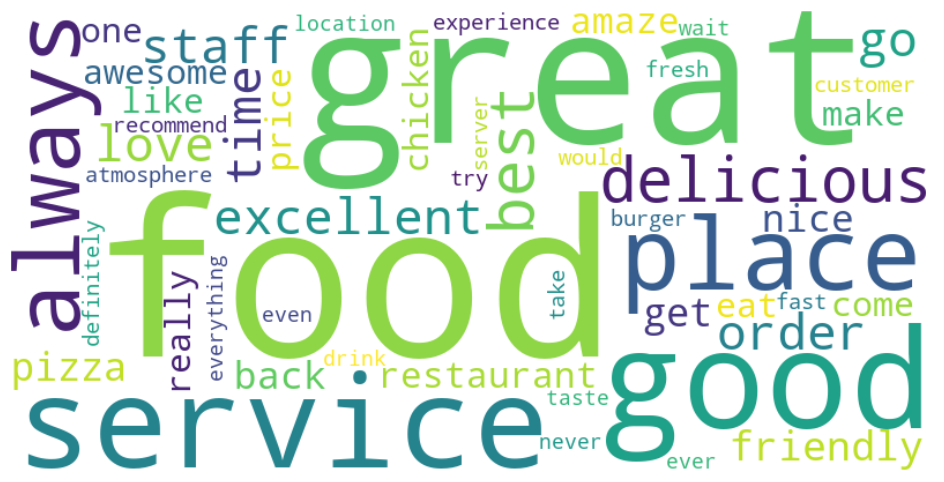

In [44]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='tfidf_vectorization.png',
    vectorized_df=tfidf_df,
    top_n=50
)

In [45]:
cooc_matrix_tfidf = MainPipeline.cooccurrence_matrix(tfidf_df)

Computing co-occurrences: 100%|██████████| 53565/53565 [00:05<00:00, 10577.04it/s]


In [46]:
display(cooc_matrix_tfidf)

,food,good,service,great,order,go,get,time,place,back,...,atl,gyro,enjoyed,biryani,coupon,better,iserver,burgers,istaff,ashley
food,0,8500,9600,8758,3278,3840,3405,3690,4388,3209,...,61,57,82,61,22,44,70,24,80,34
good,8500,0,4954,3270,2132,2311,2292,2266,2800,1833,...,27,39,54,53,19,36,35,43,30,12
service,9600,4954,0,6233,1923,2186,1901,2197,2323,2003,...,36,31,59,26,23,29,21,27,18,37
great,8758,3270,6233,0,1271,1779,1476,1875,2726,1705,...,36,38,54,24,10,25,57,37,38,65
order,3278,2132,1923,1271,0,2088,2341,2145,1688,1464,...,15,26,17,36,25,18,16,12,19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
better,44,36,29,25,18,15,21,20,30,10,...,0,0,0,1,1,0,0,1,0,0
iserver,70,35,21,57,16,13,8,22,8,21,...,0,0,0,0,0,0,0,1,0,3
burgers,24,43,27,37,12,22,17,13,16,14,...,0,0,0,0,0,1,1,0,0,0
istaff,80,30,18,38,19,13,9,13,14,8,...,0,1,0,0,0,0,0,0,0,0


## <font color='#BFD72F' size=6>6.2 Counter</font> <a class="anchor" id="6_2"></a>
  
[Back to TOC](#toc)

In [47]:
counter_text, counter_vectorizer = MainPipeline.vectorize_texts(
    dataset['tokens'], vectorizer_type='count'
)
counter_df = pd.DataFrame(counter_text.toarray(), columns=counter_vectorizer.get_feature_names_out())

In [48]:
counter_df.sample(1, random_state=12)

,10,100,1010,12,15,18,1st,20,25,30,...,wrong,year,yes,yesterday,yet,york,young,yum,yummy,zero
14684,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
counter_means = counter_df.mean(axis=0).sort_values(ascending=False).head(20)
counter_top_df = pd.DataFrame({
    'token': counter_means.index,
    'counter_weight': counter_means.values
})
bar_chart(
    data=counter_top_df,
    x='token',
    y='counter_weight',
    title='Top 20 tokens by Counter weight',
    labels={'token': 'Token', 'counter_weight': 'Average Counter Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds/counter_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x1a7e8ae60>}

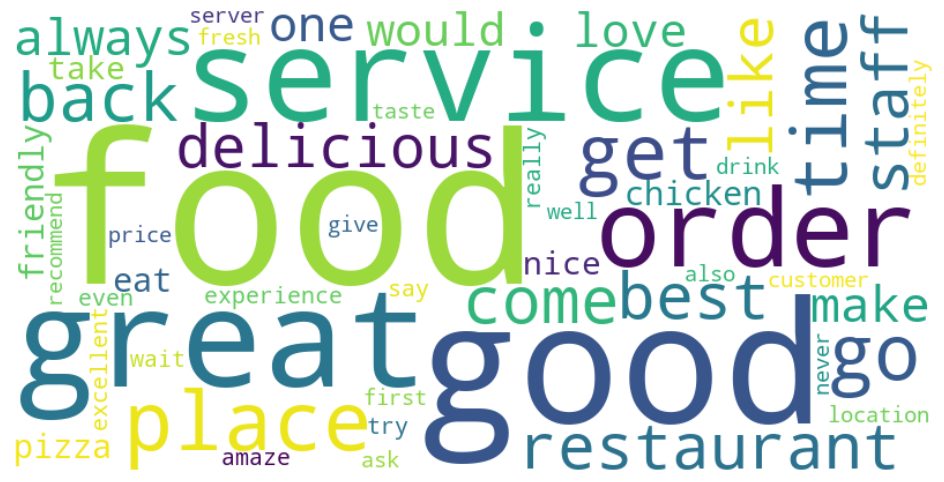

In [50]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='counter_vectorization.png',
    vectorized_df=counter_df,
    top_n=50
)

# <font color='#BFD72F' size=6>**7. Visualizations**</font> <a class="anchor" id="7"></a>
  
[Back to TOC](#toc)

<font color = 'red'>**WEEK 04**

**Word Clouds** for quick visual exploration:  
- **Size →** word frequency (the bigger, the more frequent)  
- **Color →** can encode:  
  - Part of speech (noun, adjective, verb)  
  - Sentiment (e.g., red for negative, green for positive)  

**Bar Charts**  
- General keyword frequencies  
- Keywords per rating  

**Pie Charts**  
- Group by noun/adjective/verb  
- Group by rating  

**Tree Maps**  
- Group by noun/adjective/verb  
- Group by rating  

**Circle Charts**  
- Color words by sentiment intensity (color scale)  

**Network Graphs**  
- Identify clusters and relationships (color by cluster)  

**Heatmaps**  
- Correlation of features, sentiment vs. score, etc.

**Horizontal Bar Chart**
- O que o stor costuma usar para ver o tfidf nas aulas, todo colorido.


## <font color='#BFD72F' size=6>7.1 Categories</font> <a class="anchor" id="7_1"></a>
  
[Back to TOC](#toc)

In [51]:
tfidf_df = pd.DataFrame(
    tfidf_text.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df['categoryName'] = dataset['categoryName'].values

tfidf_cat_mean = tfidf_df.groupby('categoryName').mean(numeric_only=True)

no_rows = 3  # ----> Arbitrário
cats_to_plot = (
    tfidf_df['categoryName']
    .value_counts()
    .head(no_rows)
    .index
    .tolist()
)

for cat in cats_to_plot:
    top = (
        tfidf_cat_mean.loc[cat]
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
        .rename(columns={'index': 'token', cat: 'mean_tfidf'})
    )
    bar_chart(
        data=top,
        x='token',
        y='mean_tfidf',
        title=f"{cat} - Top 10 tokens by TF-IDF weight",
        labels={'token': 'Token', 'mean_tfidf': 'TF-IDF weight'},
        top_n=10
    )


## <font color='#BFD72F' size=6>7.2 Ratings</font> <a class="anchor" id="7_2"></a>
  
[Back to TOC](#toc)

In [52]:
tfidf_df = pd.DataFrame(
    tfidf_text.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df['stars'] = pd.to_numeric(dataset['stars'])

tfidf_df = tfidf_df[tfidf_df['stars'].between(1, 5, inclusive='both')].copy()

tfidf_star_mean = tfidf_df.groupby('stars').mean(numeric_only=True).sort_index()

TOP_N = 10  # ---> Arbitrário
for star in tfidf_star_mean.index:
    top = (
        tfidf_star_mean.loc[star]
        .sort_values(ascending=False)
        .head(TOP_N)
        .reset_index()
        .rename(columns={'index': 'token', star: 'mean_tfidf'})
    )
    bar_chart(
        data=top,
        x='token',
        y='mean_tfidf',
        title=f"{int(star)}★ - Top {TOP_N} tokens by TF-IDF weight",
        labels={'token': 'Token', 'mean_tfidf': 'TF-IDF weight'},
        top_n=TOP_N
    )

## <font color='#BFD72F' size=6>7.3 Word Clouds</font> <a class="anchor" id="7_3"></a>
  
[Back to TOC](#toc)

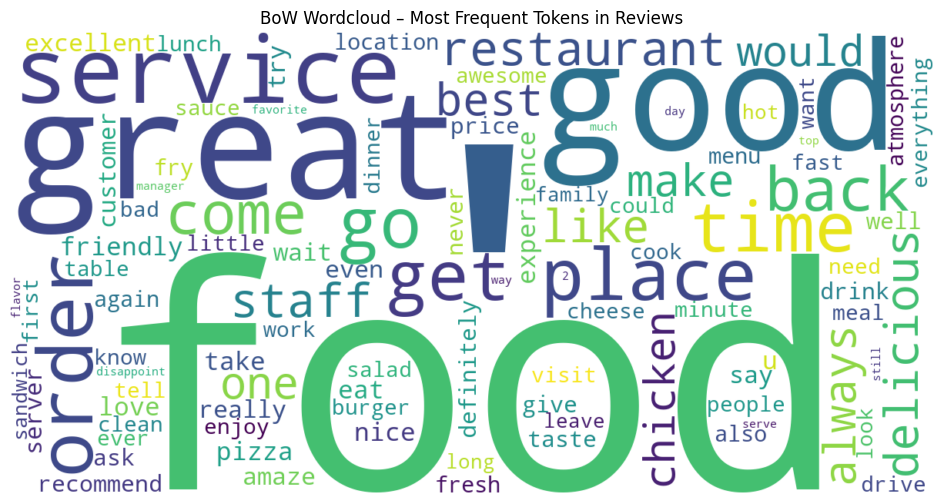

In [53]:
wordcloud_from_tokens(
    dataset["tokens"],
    max_words=100,
    title="BoW Wordcloud – Most Frequent Tokens in Reviews"
)

#### 8.3.1 Wordcloud coloured by rating


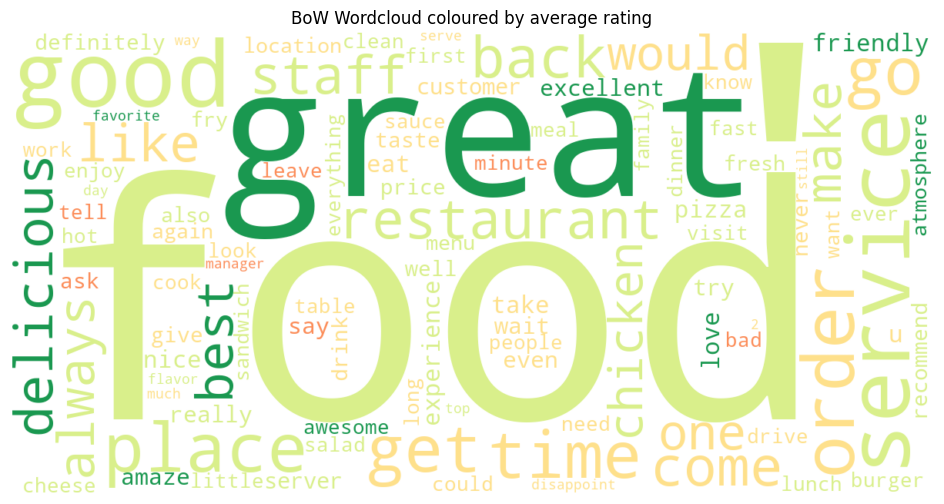

In [54]:
wordcloud_by_rating(
    token_series=dataset["tokens"],
    ratings_series=dataset["stars"],   
    max_words=100,
    title="BoW Wordcloud coloured by average rating"
)

### 8.3.2 Wordcloud coloured by Part-of-Speech (POS)



REVEIEW THIS!!!!

In [55]:
'''def ensure_string_tokens(tokens):
    if not isinstance(tokens, list):
        return []
    clean = []
    for t in tokens:
        if isinstance(t, tuple):
            clean.append(str(t[0]))  # keep word only
        else:
            clean.append(str(t))
    return clean

dataset["tokens_for_wc"] = dataset["02_transformed_text"].apply(ensure_string_tokens)'''

'def ensure_string_tokens(tokens):\n    if not isinstance(tokens, list):\n        return []\n    clean = []\n    for t in tokens:\n        if isinstance(t, tuple):\n            clean.append(str(t[0]))  # keep word only\n        else:\n            clean.append(str(t))\n    return clean\n\ndataset["tokens_for_wc"] = dataset["02_transformed_text"].apply(ensure_string_tokens)'

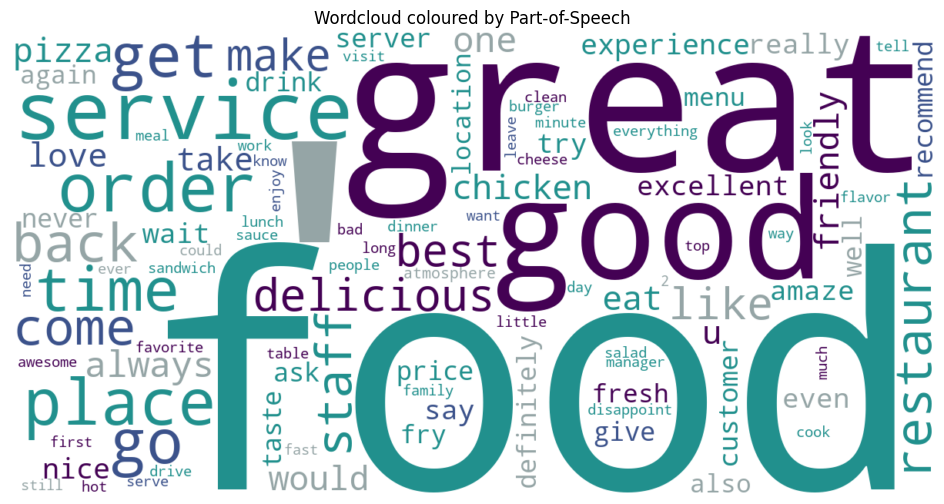

In [58]:
wc_pos = wordcloud_by_pos(
    token_series=dataset["tokens"],
    pos_series=dataset["pos_tags"],
    max_words=100,
    title="Wordcloud coloured by Part-of-Speech"

)

## <font color='#BFD72F' size=6>7.4 Tree Maps</font> <a class="anchor" id="7_4"></a>
  
[Back to TOC](#toc)

In [59]:
# Convert tokens → strings
processed = dataset["tokens"].apply(
    lambda x: " ".join(x) if isinstance(x, (list, tuple)) else str(x)
)

# Reuse same CountVectorizer your function uses
vectorizer = CountVectorizer(stop_words="english")
bow_matrix = vectorizer.fit_transform(processed)

# Convert to DataFrame
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Sum frequencies
token_freq = bow_df.sum(axis=0).sort_values(ascending=False)

# Keep only TOP N
token_freq_df = (
    pd.DataFrame({
        "token": token_freq.index,
        "frequency": token_freq.values
    })
    .head(TOP_N)
    .reset_index(drop=True)
)

token_freq_df.head()

,token,frequency
0,food,29287
1,good,18552
2,great,18105
3,service,15983
4,order,10508


In [60]:
TOP_N = 100  # or whatever number you want (e.g., 50)

# token_freq_df already exists from the cell above
token_freq_df = token_freq_df.head(TOP_N)

# Treemap
treemap_chart(
    data=token_freq_df,
    path_col=["token"],       # hierarchical path — simple (1 level)
    value_col="frequency",    # size of each tile
    title=f"Treetmap of Top {TOP_N} Most Frequent Words (BoW)"
)


### 8.4.1 Tree Map by POS

In [61]:
dataset["tokens"].head()

0    [one, word, amaze, red, fish, halibut, fry, ri...
1     [first, time, food, great, waiter, excellent, ']
2    [arecently, pleasure, din, optimist, atlanta, ...
3    [beautiful, atmosphere, delicious, food, food,...
4    ['wonderful, dinner, optimist, group, 9, great...
Name: tokens, dtype: object

In [62]:
pos_token_df = build_pos_token_freq(
    dataset["tokens"],
    dataset["pos_tags"]      # use the cleaned POS tags
)

pos_token_df.head()


,pos,token,frequency
3,OTHER,',39542
6016,NOUN,food,27770
21416,ADJ,great,17689
21467,ADJ,good,16927
6073,NOUN,service,15864


In [63]:
TOP_N = 100
pos_token_top = pos_token_df.head(TOP_N)


In [64]:
treemap_chart(
    data=pos_token_top,
    path_col=["pos", "token"],     # hierarchy: POS → word
    value_col="frequency",
    title=f"Treemap of Top {TOP_N} Words by POS"
)


In [65]:
cooc_df = build_cooccurrence_matrix_tokens(
    dataset["tokens"],   # your token column
    top_n=200                        # use 200 for strong visualizations
)

cooc_df.head()


,',food,great,good,service,order,place,go,time,get,...,authentic,keep,item,everyone,overall,atlanta,old,thru,put,expect
',0,18010,11300,10657,11660,5781,6501,5963,5903,5542,...,766,763,735,771,773,713,688,621,699,734
food,18010,0,8313,7795,9186,3140,3981,3645,3555,3286,...,580,494,432,513,522,441,427,274,402,485
great,11300,8313,0,3166,6174,1247,2506,1718,1818,1446,...,262,278,197,285,338,210,205,83,147,209
good,10657,7795,3166,0,4812,2095,2550,2242,2229,2247,...,231,323,278,274,474,242,285,154,279,401
service,11660,9186,6174,4812,0,1919,2178,2156,2189,1894,...,230,334,251,296,351,280,240,179,246,277


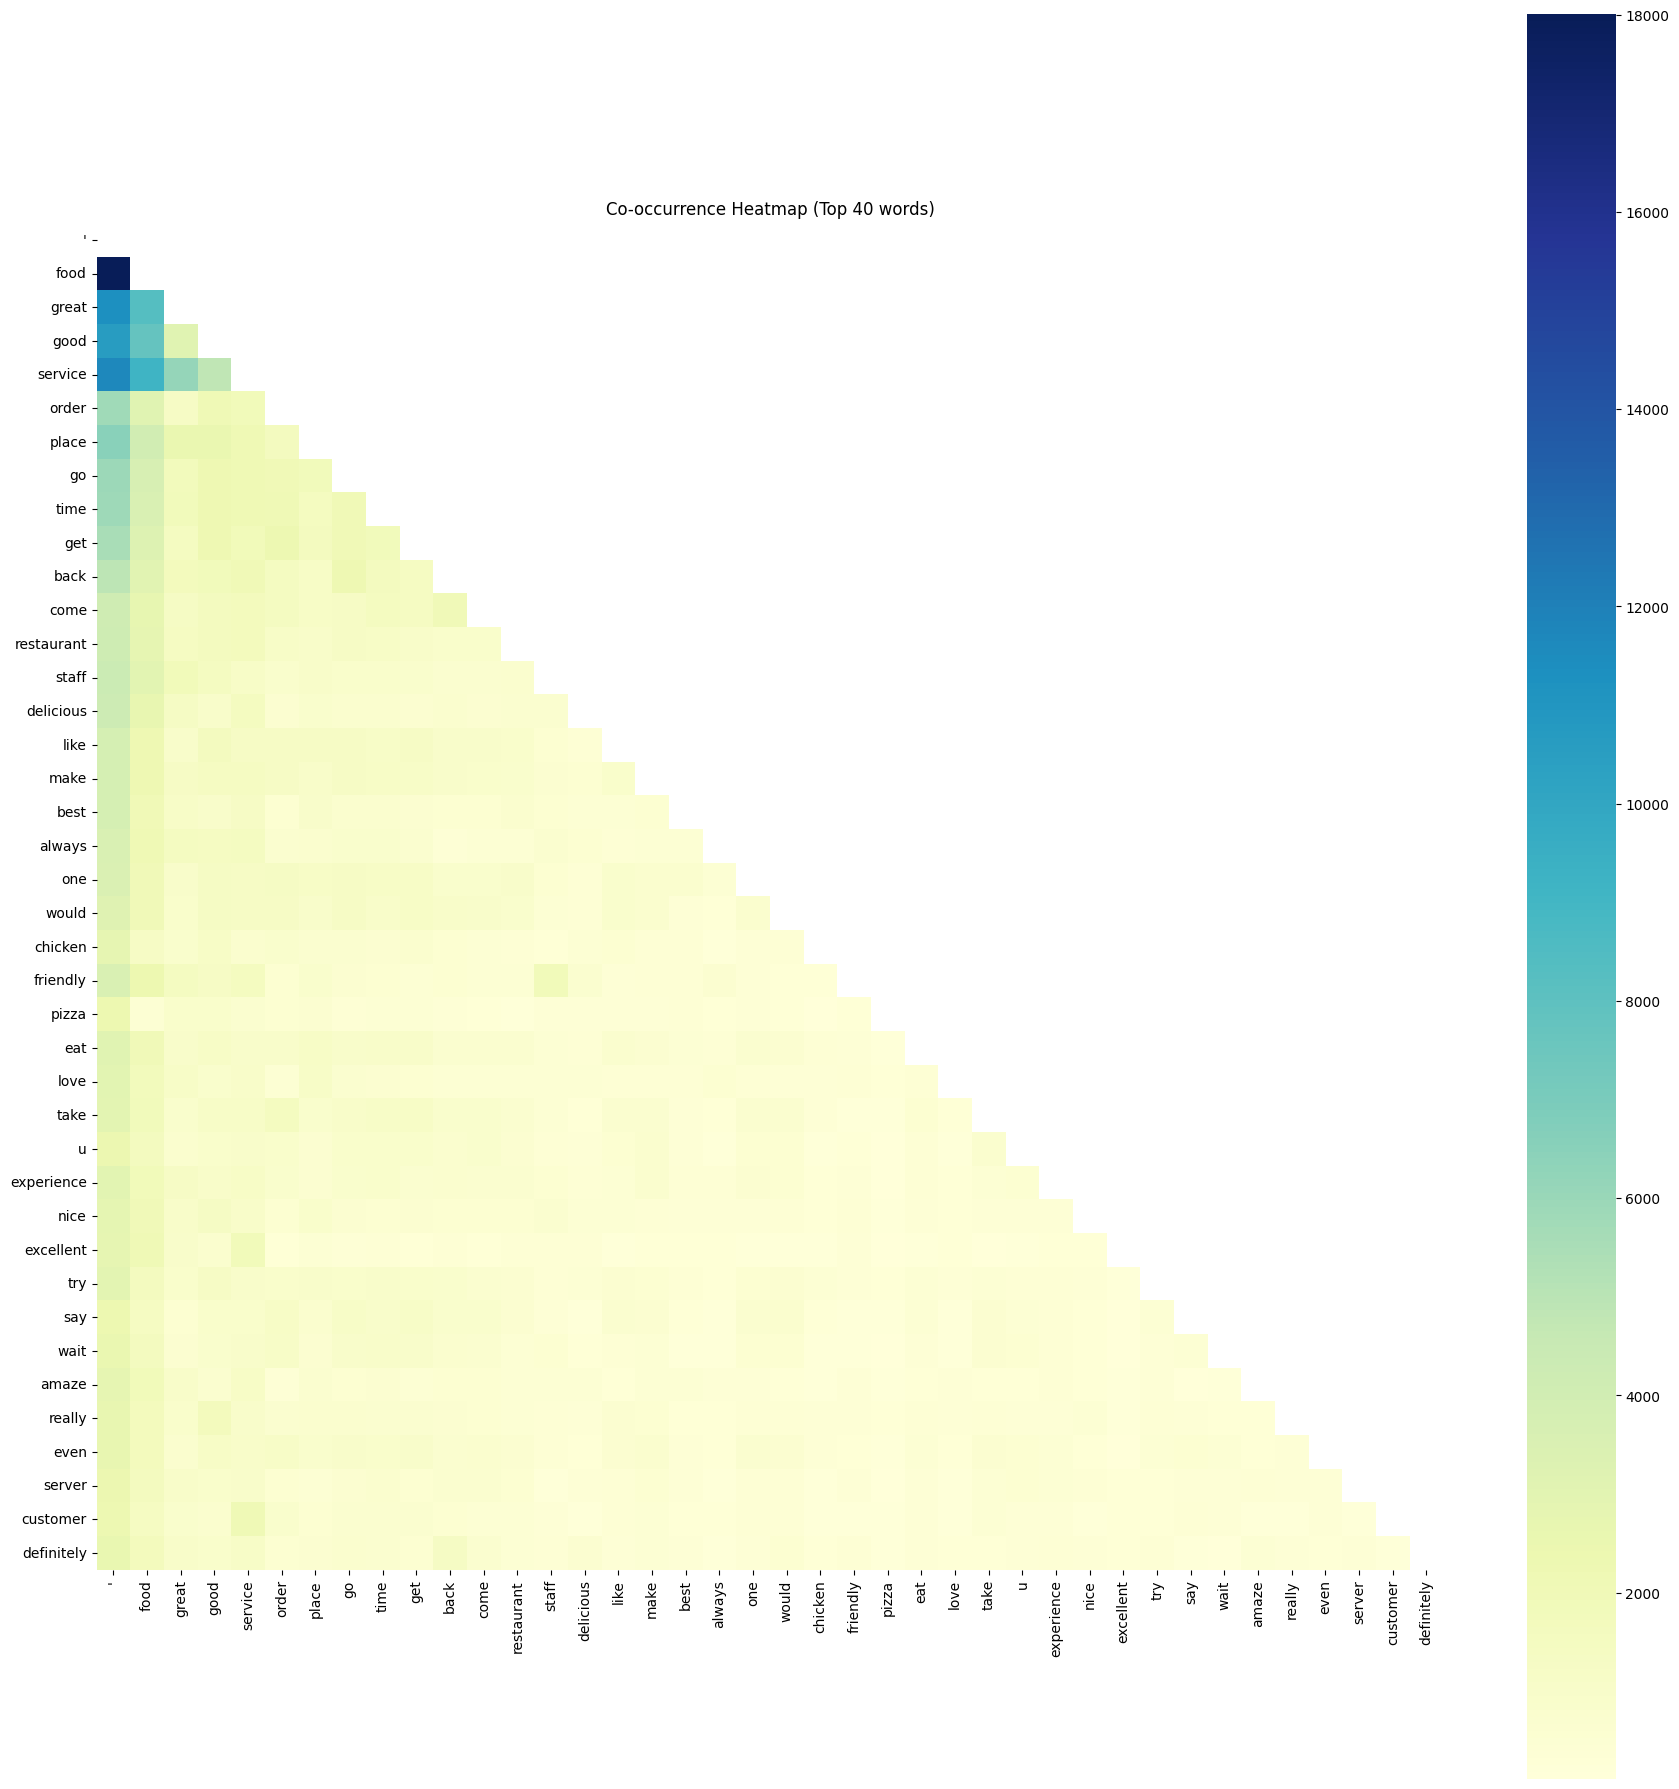

In [66]:
plot_cooccurrence_heatmap(cooc_df, top_n=40)


In [67]:
boring_words = {
    "good", "great", "place", "time", "get", "go", "make", "take", "come", "one",
    "nice", "really", "very", "always", "staff", "service", "food", "restaurant",
    "back", "order", "would", "could", "like", "best"
}

filtered_df = cooc_df.drop(index=boring_words, columns=boring_words, errors='ignore')


In [68]:
def remove_isolated_nodes(df, min_weight):
    keep = df.columns[(df > min_weight).sum(axis=1) > 0]
    return df.loc[keep, keep]

final_df = remove_isolated_nodes(filtered_df, min_weight=80)


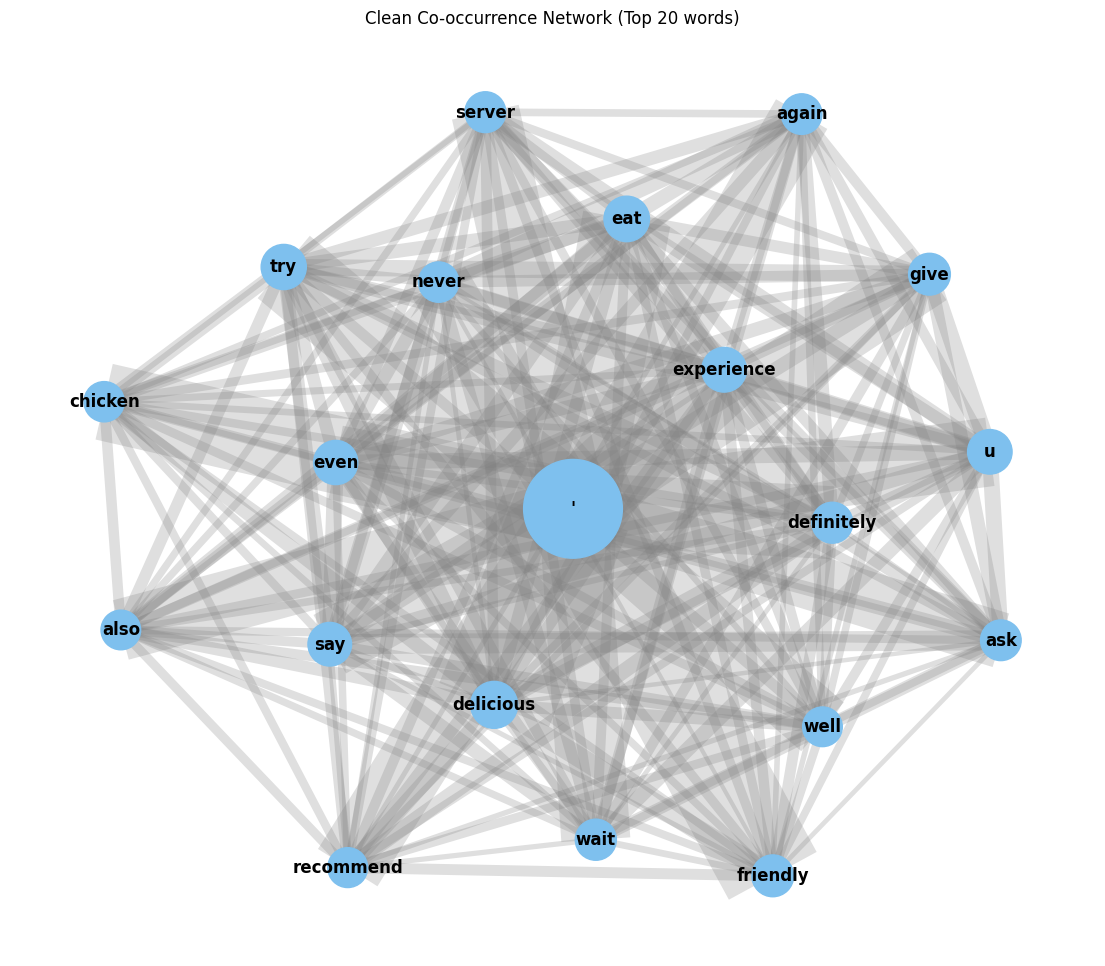

In [69]:
plot_cooccurrence_network(final_df, top_n=20, min_weight=120)
